In [5]:
!kaggle datasets download -d mhskjelvareid/dagm-2007-competition-dataset-optical-inspection

Dataset URL: https://www.kaggle.com/datasets/mhskjelvareid/dagm-2007-competition-dataset-optical-inspection
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 5.49G/5.49G [04:20<00:00, 22.6MB/s]



In [6]:
import os
import random
import numpy as np
import torch

def seed_everything(seed=42):
    # 1. Стандартный Python и хэширование
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU и GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Если вдруг видеокарт несколько

    # 4. Детерминизм для cuDNN (библиотека свёрток NVIDIA)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Вызываем функцию в начале кода
seed_everything(seed=42)

In [2]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 83.9 MB/s eta 0:00:00


In [3]:
!uv pip install segmentation_models_pytorch

Using Python 3.12.13 environment at: /usr
Resolved 54 packages in 346ms
Prepared 1 package in 20ms
Installed 1 package in 2ms
 + segmentation-models-pytorch==0.5.0


In [7]:
!mkdir dagm_data

In [8]:
!unzip -q dagm-2007-competition-dataset-optical-inspection.zip -d dagm_data/

In [9]:
!ls /content/dagm_data/DAGM_KaggleUpload/Class2/Train

0576.PNG  0648.PNG  0720.PNG  0792.PNG	0864.PNG  0936.PNG  1008.PNG  1080.PNG
0577.PNG  0649.PNG  0721.PNG  0793.PNG	0865.PNG  0937.PNG  1009.PNG  1081.PNG
0578.PNG  0650.PNG  0722.PNG  0794.PNG	0866.PNG  0938.PNG  1010.PNG  1082.PNG
0579.PNG  0651.PNG  0723.PNG  0795.PNG	0867.PNG  0939.PNG  1011.PNG  1083.PNG
0580.PNG  0652.PNG  0724.PNG  0796.PNG	0868.PNG  0940.PNG  1012.PNG  1084.PNG
0581.PNG  0653.PNG  0725.PNG  0797.PNG	0869.PNG  0941.PNG  1013.PNG  1085.PNG
0582.PNG  0654.PNG  0726.PNG  0798.PNG	0870.PNG  0942.PNG  1014.PNG  1086.PNG
0583.PNG  0655.PNG  0727.PNG  0799.PNG	0871.PNG  0943.PNG  1015.PNG  1087.PNG
0584.PNG  0656.PNG  0728.PNG  0800.PNG	0872.PNG  0944.PNG  1016.PNG  1088.PNG
0585.PNG  0657.PNG  0729.PNG  0801.PNG	0873.PNG  0945.PNG  1017.PNG  1089.PNG
0586.PNG  0658.PNG  0730.PNG  0802.PNG	0874.PNG  0946.PNG  1018.PNG  1090.PNG
0587.PNG  0659.PNG  0731.PNG  0803.PNG	0875.PNG  0947.PNG  1019.PNG  1091.PNG
0588.PNG  0660.PNG  0732.PNG  0804.PNG	0876.PNG  0948.PNG  1020.

In [10]:
from torch.utils.data import Dataset
from torch import nn
from torchvision.transforms import v2
from torch.nn import functional as F
import torch
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from PIL import Image


In [11]:
PATH = "/content/dagm_data/DAGM_KaggleUpload/Class2/Train"

segment_files = sorted(os.listdir("/content/dagm_data/DAGM_KaggleUpload/Class2/Train/Label"))
image_files = [name.replace("_label", "") for name in segment_files if os.path.exists(PATH + "/"+name.replace("_label", ""))]
len(image_files)

66

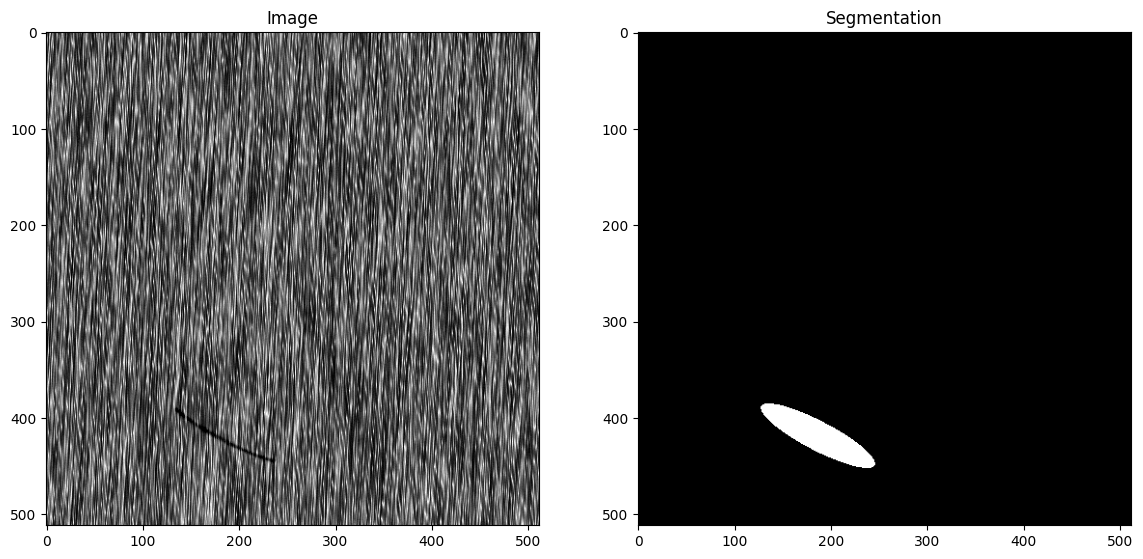

In [12]:
img = plt.imread(PATH + "/" +image_files[4])
seg_img = plt.imread(PATH + "/Label/" + segment_files[4])

_, ax = plt.subplots(1, 2, figsize=(14, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Image")
ax[1].imshow(seg_img, cmap='gray')
ax[1].set_title("Segmentation")
plt.show()

In [27]:
class MyDataset(Dataset):
  def __init__(self, image_files, segment_files, PATH="/content/dagm_data/DAGM_KaggleUpload/Class2/Train/", Train=True) -> None:
    super().__init__()

    self.image_files = [PATH + i for i in image_files]
    self.segment_files = [PATH + "Label/" + i for i in segment_files]
    if Train:
      self.transform= v2.Compose(
          [
          v2.Resize((256, 256)),
          v2.RandomHorizontalFlip(p=0.5),
          v2.RandomVerticalFlip(p=0.5),
          v2.ToImage(),
          v2.ToDtype(torch.float32, scale=True),
          v2.Normalize(mean=[0.5], std=[0.5])
          ]
      )
    else:
      self.transform= v2.Compose(
          [
          v2.Resize((256, 256)),
          v2.ToImage(),
          v2.ToDtype(torch.float32, scale=True),
          v2.Normalize(mean=[0.5], std=[0.5])
          ]
      )



  def __getitem__(self, index):

    img = Image.open(self.image_files[index]).convert("L")
    mask = Image.open(self.segment_files[index]).convert("L")


    img, mask = self.transform(img, mask)

    mask = (mask>0.5).float()

    return (img, mask)

  def __len__(self):

    return len(self.image_files)

torch.set_printoptions(threshold=float('inf'))
data = MyDataset(image_files, segment_files)

len(data)

66

torch.Size([1, 256, 256]) torch.Size([1, 256, 256])


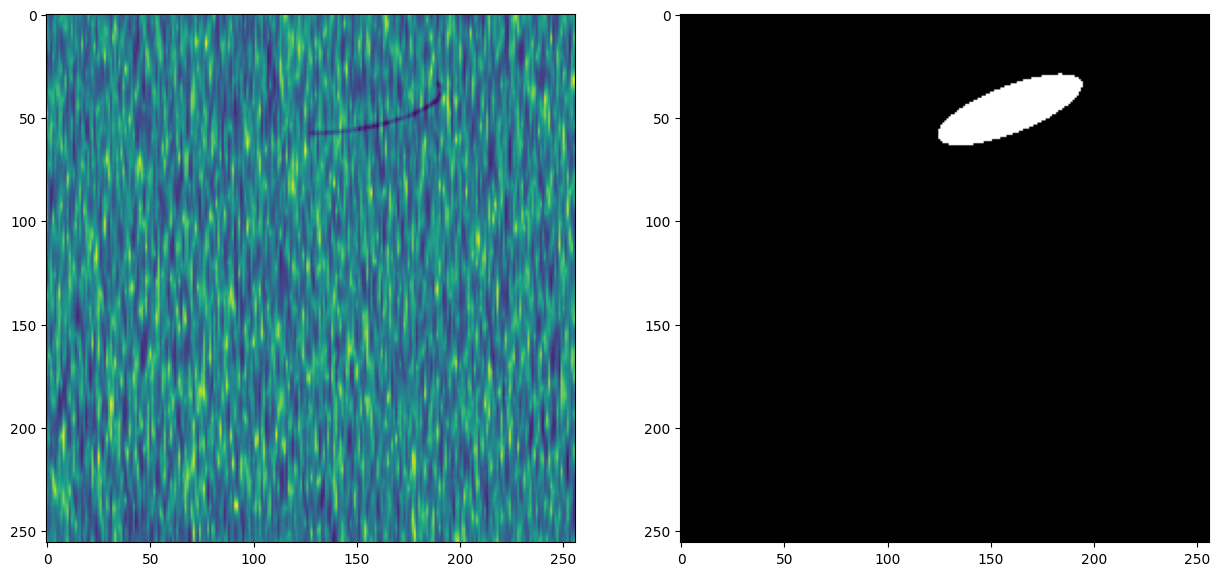

In [15]:
img, mask = data[7]
print(img.shape, mask.shape)
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(img.permute(1, 2, 0))
ax[1].imshow(mask.permute(1,2,0), cmap='gray')
plt.show()

In [16]:
mask.unique()

tensor([0., 1.])

In [17]:
from torch.utils.data.dataloader import DataLoader
train_size = int(len(data) * 0.9)
val_size = len(data) - train_size

train_data, val_data = torch.utils.data.random_split(data, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=10, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=10, shuffle=False)

In [18]:
!uv pip install torchmetrics

Using Python 3.12.13 environment at: /usr
Resolved 33 packages in 179ms
Prepared 2 packages in 73ms
Installed 2 packages in 7ms
 + lightning-utilities==0.15.3
 + torchmetrics==1.9.0


In [60]:
from torchmetrics import JaccardIndex
import segmentation_models_pytorch as smp


jacard = JaccardIndex(threshold=0.5, task="binary", average="none")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
)

optim = torch.optim.AdamW(model.parameters(), 1e-2)
model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [61]:
for param in model.parameters():
  param.requires_grad = False

for layer in list(model.decoder.children())[-5:]:
  for param in layer.parameters():
    param.requires_grad = True

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
jacard = jacard.to(device)

In [62]:
class DiceLoss(nn.Module):
  def __init__(self, smooth=1e-7):
    super().__init__()

    self.smooth = smooth

  def forward(self, output, targets):

    outputs = torch.sigmoid(output)

    outputs = outputs.view(-1)
    targets = targets.view(-1)

    interseption = (outputs * targets).sum()

    dice_score = (2. * interseption + self.smooth)/(outputs.sum() + targets.sum() + self.smooth)

    return 1 - dice_score


In [63]:
from tqdm.notebook import tqdm
import seaborn as sns

criterion = DiceLoss()
epochs = 40
avg_train_loss = []
avg_val_dice = []
avg_val_iou = []
for epoch in tqdm(range(epochs)):
  model.train()
  train_loss = 0

  for X_batch, Y_batch in tqdm(train_loader):
    X_batch = X_batch.to(device)
    Y_batch = Y_batch.to(device)
    Y_pred = model(X_batch)
    loss = criterion(Y_pred, Y_batch)
    train_loss += loss.item()

    optim.zero_grad()

    loss.backward()
    optim.step()

  avg_train_loss.append(train_loss/len(train_loader))

  model.eval()
  val_loss_dice = 0
  val_loss_iou = 0
  with torch.no_grad():
    for X_val, Y_val in val_loader:
      X_val = X_val.to(device)
      Y_val = Y_val.to(device)

      Y_pred = model(X_val)

      loss = criterion(Y_pred, Y_val)
      val_loss_dice += loss.item()

      val_loss_iou += jacard(torch.sigmoid(Y_pred), Y_val).to(device).item()



  avg_val_dice.append(val_loss_dice/len(val_loader))
  avg_val_iou.append(val_loss_iou/len(val_loader))
  print(f"Epoch:{epoch} | Train: {avg_train_loss[-1] :.6f} | Val: {avg_val_dice[-1]:.6f} | Val: {avg_val_iou[-1]:.6f}")



  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

Epoch:0 | Train: 0.958022 | Val: 0.979580 | Val: 0.010315


  0%|          | 0/6 [00:00<?, ?it/s]

Epoch:1 | Train: 0.939845 | Val: 0.978367 | Val: 0.010914


...

Epoch:37 | Train: 0.247653 | Val: 0.483970 | Val: 0.366080


  0%|          | 0/6 [00:00<?, ?it/s]

Epoch:38 | Train: 0.224141 | Val: 0.309300 | Val: 0.636765


  0%|          | 0/6 [00:00<?, ?it/s]

Epoch:39 | Train: 0.226521 | Val: 0.266245 | Val: 0.647737


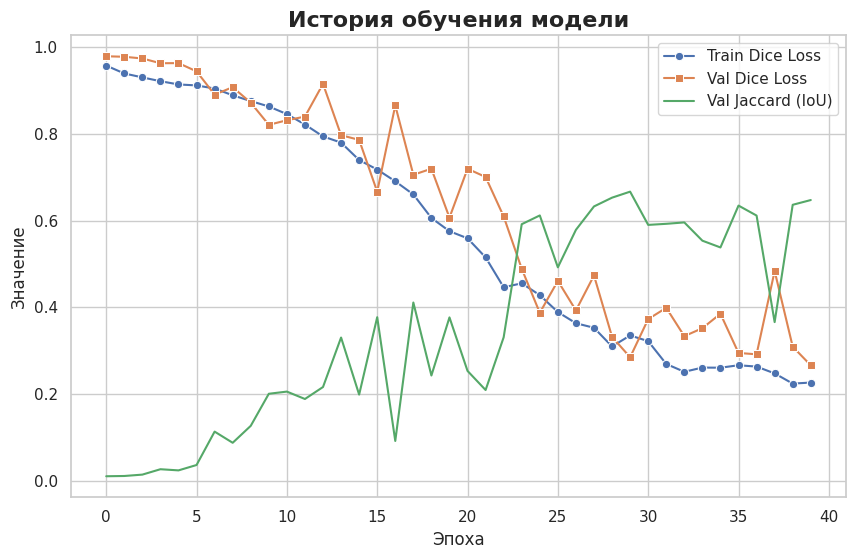

In [64]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


sns.lineplot(data=avg_train_loss, label="Train Dice Loss", marker="o")
sns.lineplot(data=avg_val_dice, label="Val Dice Loss", marker="s")
sns.lineplot(data=avg_val_iou, label="Val Jaccard (IoU)")


plt.title("История обучения модели", fontsize=16, fontweight="bold")
plt.xlabel("Эпоха", fontsize=12)
plt.ylabel("Значение", fontsize=12)

plt.legend()
plt.show()


In [23]:
!ls /content/dagm_data/DAGM_KaggleUpload/Class2/Test/Label

0003_label.PNG	0124_label.PNG	0206_label.PNG	0319_label.PNG	0461_label.PNG
0007_label.PNG	0128_label.PNG	0207_label.PNG	0320_label.PNG	0467_label.PNG
0009_label.PNG	0133_label.PNG	0210_label.PNG	0339_label.PNG	0468_label.PNG
0013_label.PNG	0137_label.PNG	0218_label.PNG	0356_label.PNG	0470_label.PNG
0014_label.PNG	0143_label.PNG	0224_label.PNG	0369_label.PNG	0475_label.PNG
0017_label.PNG	0145_label.PNG	0230_label.PNG	0377_label.PNG	0483_label.PNG
0033_label.PNG	0146_label.PNG	0236_label.PNG	0397_label.PNG	0488_label.PNG
0039_label.PNG	0148_label.PNG	0238_label.PNG	0401_label.PNG	0490_label.PNG
0045_label.PNG	0159_label.PNG	0248_label.PNG	0411_label.PNG	0503_label.PNG
0057_label.PNG	0164_label.PNG	0251_label.PNG	0423_label.PNG	0514_label.PNG
0063_label.PNG	0169_label.PNG	0258_label.PNG	0428_label.PNG	0515_label.PNG
0070_label.PNG	0179_label.PNG	0279_label.PNG	0429_label.PNG	0519_label.PNG
0076_label.PNG	0181_label.PNG	0288_label.PNG	0436_label.PNG	0529_label.PNG
0083_label.PNG	0197_label

In [65]:
seg_test = sorted(os.listdir("/content/dagm_data/DAGM_KaggleUpload/Class2/Test/Label"))
img_test = sorted(m for m in os.listdir("/content/dagm_data/DAGM_KaggleUpload/Class2/Test") if m.replace(".PNG", "_label.PNG") in seg_test)

data_val = MyDataset(img_test, seg_test, PATH="/content/dagm_data/DAGM_KaggleUpload/Class2/Test/", Train=False)
test_loader = torch.utils.data.DataLoader(data_val, batch_size=10, shuffle=False)

model.eval()

with torch.no_grad():
  jac = 0
  dice = 0
  for X_batch, Y_batch in test_loader:
    X_batch = X_batch.to(device)
    Y_batch = Y_batch.to(device)

    Y_pred = model(X_batch)
    loss_1 = jacard(torch.sigmoid(Y_pred), Y_batch)
    loss_2 = criterion(Y_pred,Y_batch)
    jac += loss_1.item()
    dice += loss_2.item()

  print(f"Test Jaccard: {jac/len(test_loader):.4f}\nTest Dice: {dice/len(test_loader):.4f}")








Test Jaccard: 0.6592
Test Dice: 0.2696
